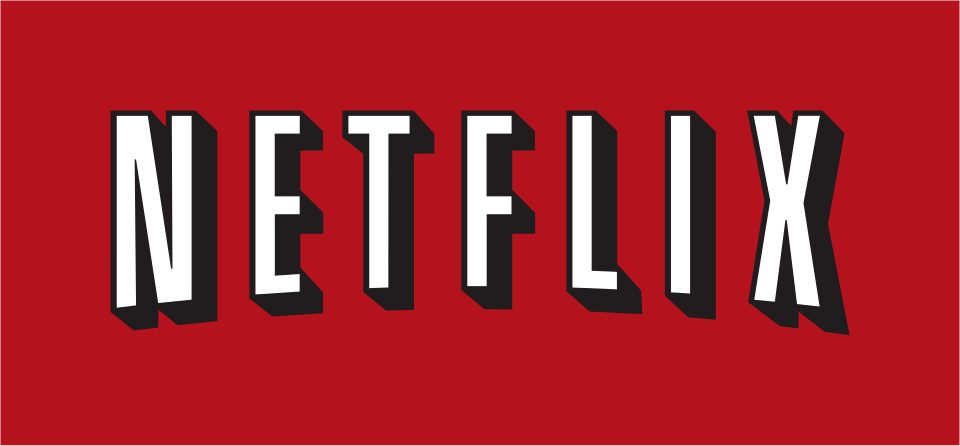

# ETL & EDA

| Coluna | Descrição |
|---------|------------|
| `show_id` | Identificador único de cada título no catálogo. |
| `type` | Tipo do conteúdo (`Movie` ou `TV Show`). |
| `title` | Título do filme ou série. |
| `director` | Diretor(a) responsável pela obra. |
| `cast` | Principais atores e atrizes do elenco. |
| `country` | País de origem da produção. |
| `date_added` | Data em que o título foi adicionado à Netflix. |
| `release_year` | Ano de lançamento original do título. |
| `rating` | Classificação indicativa original fornecida pela Netflix. |
| `duration` | Duração do filme (em minutos) ou número de temporadas da série. |
| `listed_in` | Gêneros ou categorias atribuídas ao título pela Netflix. |
| `description` | Breve sinopse ou descrição do conteúdo. |
| `main_country` | País principal da produção, extraído da coluna `country`. |
| `continent` | Continente associado ao país principal de origem. |
| `language` | Idioma predominante do título. |
| `genre` | Gênero principal do filme, derivado da coluna `listed_in`. |
| `rating_group` | Agrupamento simplificado das classificações indicativas (ex.: Kids, Teens, Adults, Unknown). |

## ETL - Extrair, Transformar e Carregar

In [181]:
'''
Verificar os arquivos:
- src/extract.py
- src/cleaning.py
- src/feature_engineering.py
- src/load.py
'''

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.load import save_processed_data

save_processed_data('../data/raw/netflix_titles.csv')

Arquivos salvos com sucesso!


## Análise Exploratória de Dados (EDA)

### Importação das bibliotecas e Leitura do dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import squarify
import geopandas as gpd
import warnings

# Exibir todas as linhas
pd.set_option('display.max_rows', None)
# Exibir todas as colunas
pd.set_option('display.max_columns', None)
warnings.filterwarnings("ignore")
#!pip freeze > requirements.txt

netflix = pd.read_csv('../data/processed/netflix.csv')
netflix_directors = pd.read_csv('../data/processed/netflix_directors.csv')
netflix_cast = pd.read_csv('../data/processed/netflix_cast.csv')

netflix_movies = netflix[netflix['type'] == 'Movie'].reset_index(drop=True).copy()
netflix_tv = netflix[netflix['type'] == 'TV Show'].reset_index(drop=True).copy()

In [183]:
pd.DataFrame({
    'column': netflix.columns,
    'dtype': netflix.dtypes.astype(str),
    'non_null': netflix.count().values
})

,column,dtype,non_null
type,type,str,8807
title,title,str,8807
description,description,str,8807
director,director,str,8807
n_directors,n_directors,int64,8807
cast,cast,str,8807
n_cast_members,n_cast_members,int64,8807
country,country,str,8807
n_countries,n_countries,int64,8807
main_country,main_country,str,8807


In [184]:
netflix.shape

(8807, 24)

In [185]:
netflix.duplicated().sum()

np.int64(0)

In [186]:
netflix.isnull().sum()

type                 0
title                0
description          0
director             0
n_directors          0
cast                 0
n_cast_members       0
country              0
n_countries          0
main_country         0
continent            0
language             0
release_year         0
release_decade       0
date_added           0
year_added           0
delay_added          0
rating               0
rating_group         0
duration             0
duration_category    0
listed_in            0
n_genres             0
genre                0
dtype: int64

In [187]:
netflix.head()

,type,title,description,director,n_directors,cast,n_cast_members,country,n_countries,main_country,continent,language,release_year,release_decade,date_added,year_added,delay_added,rating,rating_group,duration,duration_category,listed_in,n_genres,genre
0,Movie,Dick Johnson Is Dead,"As her father nears the end of his life, filmm...",Kirsten Johnson,1,Not Informed,0,United States,1,United States,North America,English,2020,2020,2021-09-25,2021,1,PG-13,Teen,90,Feature Film,Documentaries,1,Documentary
1,TV Show,Blood & Water,"After crossing paths at a party, a Cape Town t...",Not Informed,0,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",19,South Africa,1,South Africa,Africa,English,2021,2020,2021-09-24,2021,0,TV-MA,Adult,2,Short Series,"International TV Shows, TV Dramas, TV Mysteries",3,International
2,TV Show,Ganglands,To protect his family from a powerful drug lor...,Julien Leclercq,1,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",9,Unknown,0,Unknown,Unknown,Unknown,2021,2020,2021-09-24,2021,0,TV-MA,Adult,1,Limited Series,"Crime TV Shows, International TV Shows, TV Act...",3,Crime
3,TV Show,Jailbirds New Orleans,"Feuds, flirtations and toilet talk go down amo...",Not Informed,0,Not Informed,0,Unknown,0,Unknown,Unknown,Unknown,2021,2020,2021-09-24,2021,0,TV-MA,Adult,1,Limited Series,"Docuseries, Reality TV",2,Documentary
4,TV Show,Kota Factory,In a city of coaching centers known to train I...,Not Informed,0,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",8,India,1,India,Asia,Hindi,2021,2020,2021-09-24,2021,0,TV-MA,Adult,2,Short Series,"International TV Shows, Romantic TV Shows, TV ...",3,International


### Proporção de filmes e séries no catálogo da Netflix

In [188]:
netflix_type = netflix['type'].value_counts().reset_index()
netflix_type['proportion'] = (netflix_type['count'] / netflix_type['count'].sum() * 100).round(2)
netflix_type


,type,count,proportion
0,Movie,6131,69.62
1,TV Show,2676,30.38


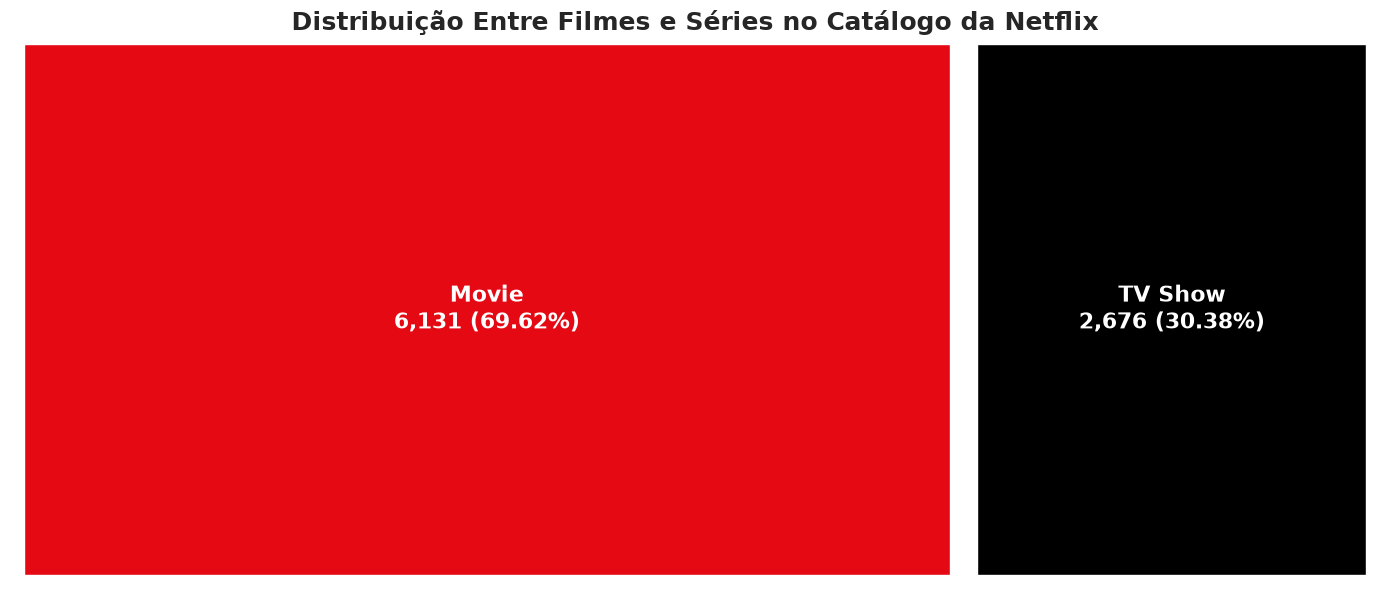

In [189]:
labels = [f"{row['type']}\n{row['count']:,} ({row['proportion']:.2f}%)" for _, row in netflix_type.iterrows()]
sizes = netflix_type['count']
colors = ['#E50914', '#000000']

plt.figure(figsize=(14, 6))
squarify.plot(
    sizes=sizes,
    label=labels,
    color=colors,
    alpha=1,
    text_kwargs={'color': 'white', 'fontsize': 16, 'fontweight': 'bold'},
    pad=True
)
plt.axis('off')
plt.title('Distribuição Entre Filmes e Séries no Catálogo da Netflix', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

## Filmes

### Quantidades de Produções de Filmes por País

In [190]:
movies_country = netflix_movies['main_country'].value_counts().reset_index()
movies_country['proportion'] = (movies_country['count'] / netflix_type['count'].sum() * 100).round(2)
movies_country.head(20)

,main_country,count,proportion
0,United States,2364,26.84
1,India,927,10.53
2,Unknown,440,5.00
3,United Kingdom,382,4.34
4,Canada,187,2.12
5,France,149,1.69
6,Spain,129,1.46
7,Egypt,98,1.11
8,Nigeria,87,0.99
9,Mexico,86,0.98


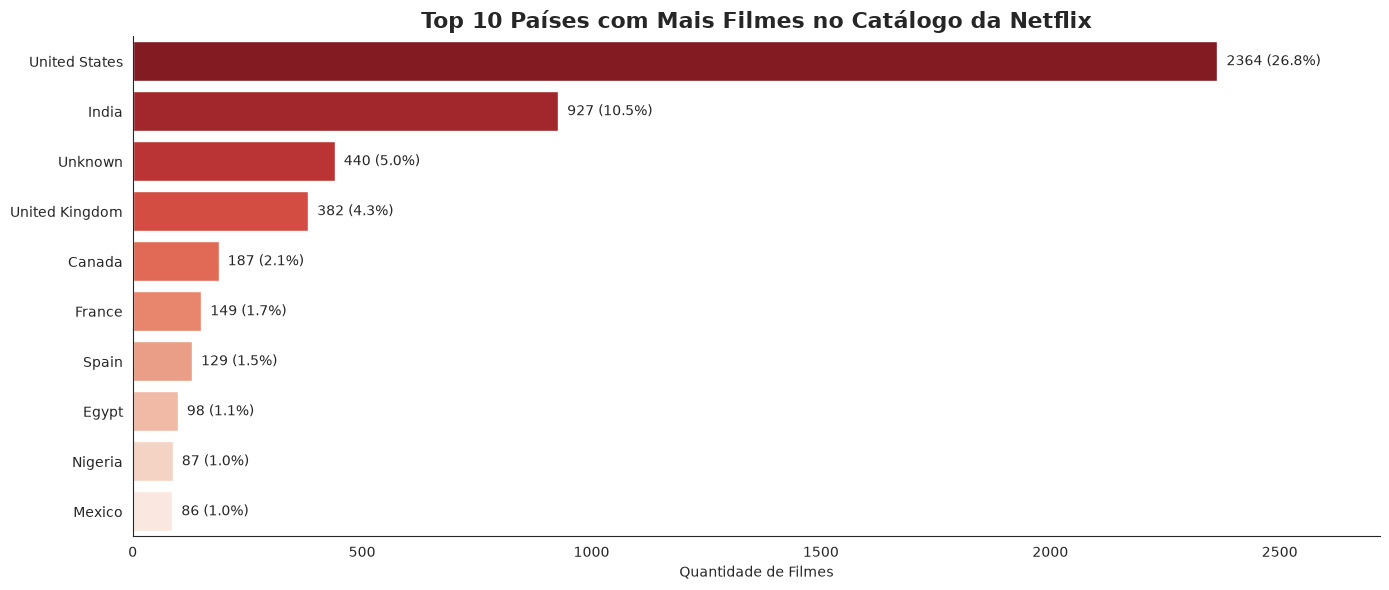

In [191]:
plt.figure(figsize=(14, 6))

top10 = movies_country.head(10)

ax = sns.barplot(data=top10, x='count', y='main_country', palette='Reds_r')

for i, (_, row) in enumerate(top10.iterrows()):
    ax.text(
        row['count'] + 20,
        i,
        f"{row['count']} ({row['proportion']:.1f}%)",
        va='center',
        fontsize=10
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title('Top 10 Países com Mais Filmes no Catálogo da Netflix',fontsize=16,fontweight='bold')
plt.xlabel('Quantidade de Filmes')
plt.ylabel('')
plt.xlim(0, top10['count'].max() * 1.15)
plt.tight_layout()
plt.show()

### Quantidades de Produções de Filmes por Continente

In [192]:
movies_continent = netflix_movies['continent'].value_counts().reset_index()
movies_continent['proportion'] = (movies_continent['count'] / netflix_type['count'].sum() * 100).round(2)
movies_continent

,continent,count,proportion
0,North America,2637,29.94
1,Asia,1530,17.37
2,Europe,1046,11.88
3,Unknown,446,5.06
4,Africa,232,2.63
5,South America,162,1.84
6,Oceania,76,0.86
7,Central America,2,0.02


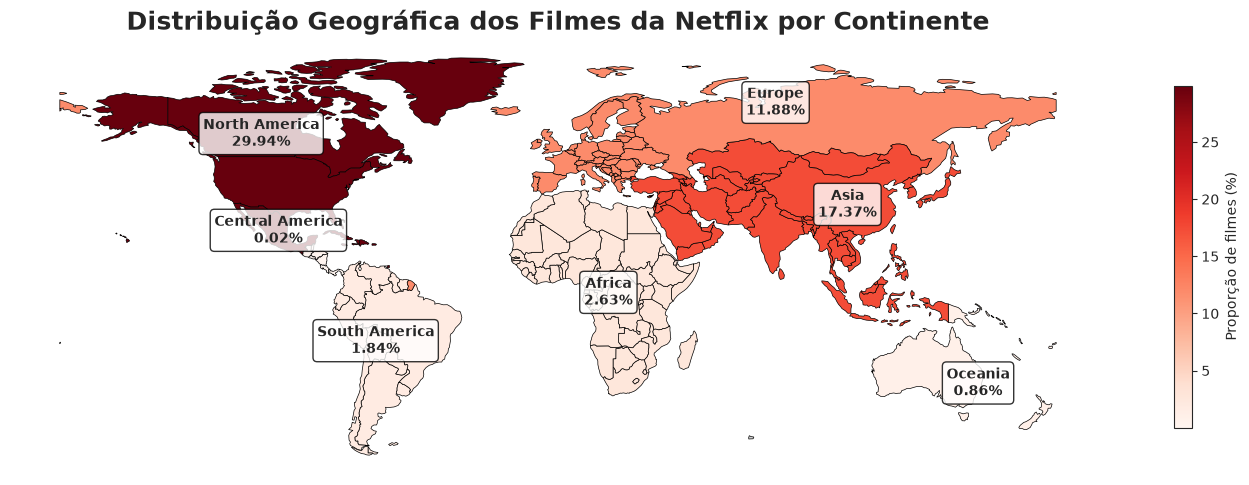

In [193]:
# Dados
movies_continent = pd.DataFrame({
    'continent': ['North America', 'Asia', 'Europe', 'Unknown', 'Africa', 'South America', 'Oceania', 'Central America'],
    'count': [2637, 1530, 1046, 446, 232, 162, 76, 2],
    'proportion': [29.94, 17.37, 11.88, 5.06, 2.63, 1.84, 0.86, 0.02]})

# Carregar mapa-múndi (compatível com GeoPandas >= 1.0)
world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")
# Ajustar continentes
world['continent'] = world['CONTINENT']
# Separar América Central da América do Norte
central_america = ['Belize', 'Costa Rica', 'El Salvador', 'Guatemala','Honduras', 'Nicaragua', 'Panama']
world.loc[world['ADMIN'].isin(central_america), 'continent'] = 'Central America'
# Remover Antártida
world = world[world['continent'] != 'Antarctica']
# Juntar os dados ao mapa
world = world.merge(movies_continent[['continent', 'proportion']],on='continent',how='left')
# Plot
fig, ax = plt.subplots(figsize=(14, 6))

world.plot(
    column='proportion', cmap='Reds', linewidth=0.5, edgecolor='black', legend=True,
    legend_kwds={'label': 'Proporção de filmes (%)', 'shrink': 0.6},
    missing_kwds={'color': 'lightgrey','label': 'Sem dados'},ax=ax)

# Rótulos dos continentes
continents = world.dissolve(by='continent')

for continent, row in continents.iterrows():

    if continent == 'Unknown':
        continue

    centroid = row.geometry.centroid

    prop = movies_continent.loc[
        movies_continent['continent'] == continent,
        'proportion'
    ]

    if len(prop) > 0:

        x, y = centroid.x, centroid.y

        # Ajustes manuais para melhor posicionamento
        if continent == 'North America':
            x -= 15
        elif continent == 'South America':
            x -= 5
        elif continent == 'Europe':
            y += 8
        elif continent == 'Asia':
            x += 20
        elif continent == 'Africa':
            y -= 5
        elif continent == 'Oceania':
            x += 15
            y -= 5
        elif continent == 'Central America':
            x -= 15
            y += 10

        ax.text(
            x,
            y,
            f'{continent}\n{prop.values[0]:.2f}%', ha='center', va='center', fontsize=10, fontweight='bold', bbox=dict(
                facecolor='white',
                edgecolor='black',
                alpha=0.8,
                boxstyle='round,pad=0.3'
            )
        )

ax.set_title('Distribuição Geográfica dos Filmes da Netflix por Continente',fontsize=18,fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

### Quantidades de Produções de Filmes por Língua

In [194]:
movies_language = netflix_movies['language'].value_counts().reset_index()
movies_language['proportion'] = (movies_language['count'] / netflix_type['count'].sum() * 100).round(2)
movies_language.head(20)

,language,count,proportion
0,English,3174,36.04
1,Hindi,927,10.53
2,Unknown,446,5.06
3,Spanish,322,3.66
4,French,160,1.82
5,Arabic,149,1.69
6,German,93,1.06
7,Japanese,85,0.97
8,Indonesian,83,0.94
9,Turkish,81,0.92


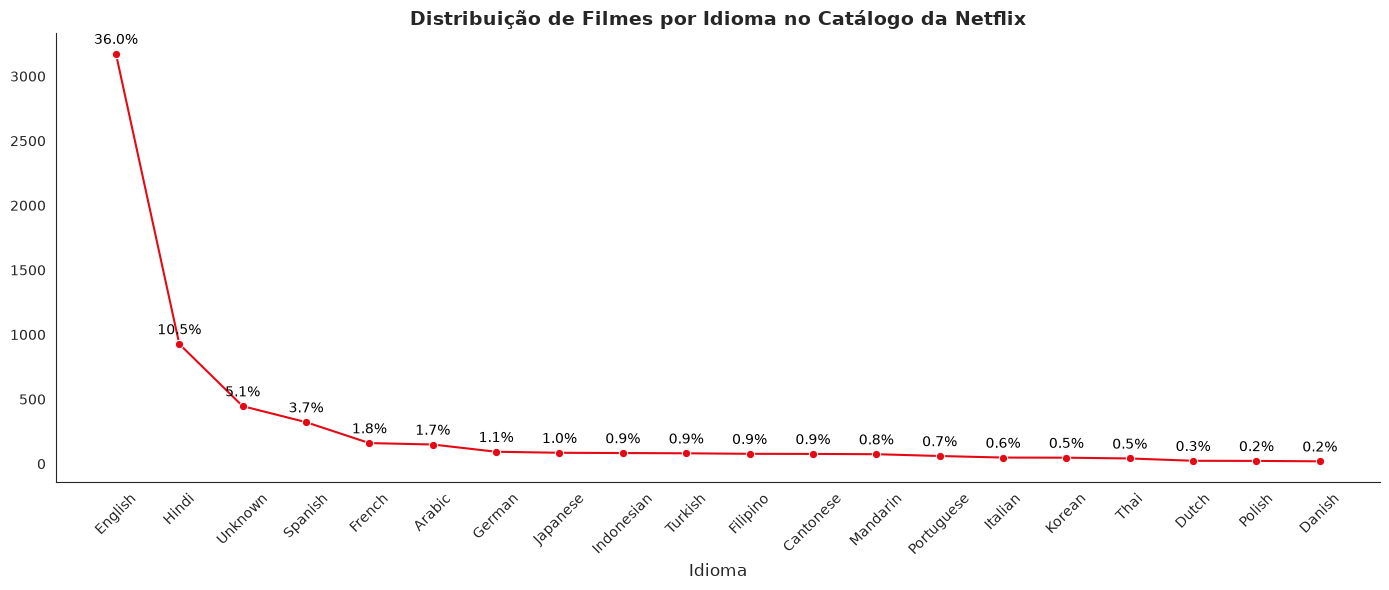

In [195]:
plt.figure(figsize=(14, 6))
ax = sns.lineplot(
    data=movies_language.head(20),
    x='language',
    y='count',
    marker='o',
    color='#E50914'
)

# Adicionando porcentagem acima dos pontos
for x, y, prop in zip(movies_language['language'].head(20),
                      movies_language['count'].head(20),
                      movies_language['proportion'].head(20)):
    ax.text(
        x, y + 50, f'{prop:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title('Distribuição de Filmes por Idioma no Catálogo da Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Idioma', fontsize=12)
plt.ylabel('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Quantidades de Produções de Filmes por Gênero

In [196]:
movies_genre = netflix_movies['genre'].value_counts().reset_index()
movies_genre['proportion'] = (movies_genre['count'] / movies_genre['count'].sum() * 100).round(2)
movies_genre

,genre,count,proportion
0,Drama,1600,26.10
1,Comedy,1544,25.18
2,Action & Adventure,859,14.01
3,Documentary,829,13.52
4,Family,605,9.87
5,Horror,275,4.49
6,Other,170,2.77
7,International,128,2.09
8,Crime,65,1.06
9,Anime,21,0.34


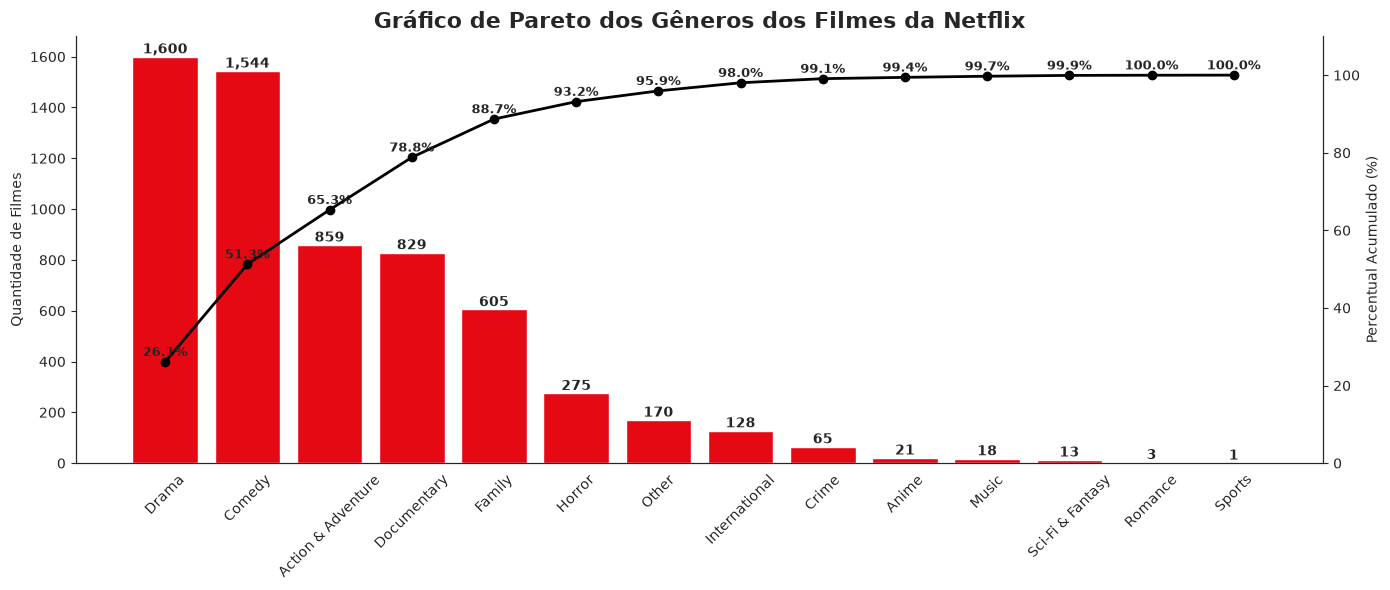

In [197]:
# Percentual acumulado
movies_genre['cumulative'] = movies_genre['proportion'].cumsum()

# Gráfico
fig, ax1 = plt.subplots(figsize=(14, 6))

bars = ax1.bar(
    movies_genre['genre'],
    movies_genre['count'],
    color='#E50914'
)

# Quantidades nas barras
for bar in bars:
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{int(bar.get_height()):,}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

ax1.set_ylabel('Quantidade de Filmes')
ax1.tick_params(axis='x', rotation=45)
ax1.spines['top'].set_visible(False)

# Linha do Pareto
ax2 = ax1.twinx()

ax2.plot(
    movies_genre['genre'],
    movies_genre['cumulative'],
    color='black',
    marker='o',
    linewidth=2
)

# Percentuais acumulados
for i, value in enumerate(movies_genre['cumulative']):
    ax2.text(
        i,
        value + 1.5,
        f'{value:.1f}%',
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

ax2.set_ylabel('Percentual Acumulado (%)')
ax2.set_ylim(0, 110)
ax2.spines['top'].set_visible(False)

plt.title(
    'Gráfico de Pareto dos Gêneros dos Filmes da Netflix',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

### Quantidades de Produções de Filmes por Classificação Etária

In [198]:
movies_rating = netflix_movies['rating_group'].value_counts().reset_index()
movies_rating['proportion'] = (movies_rating['count'] / movies_rating['count'].sum() * 100).round(2)
movies_rating

,rating_group,count,proportion
0,Adult,2862,46.68
1,Teen,2457,40.08
2,Family,413,6.74
3,Kids,316,5.15
4,Unknown,83,1.35


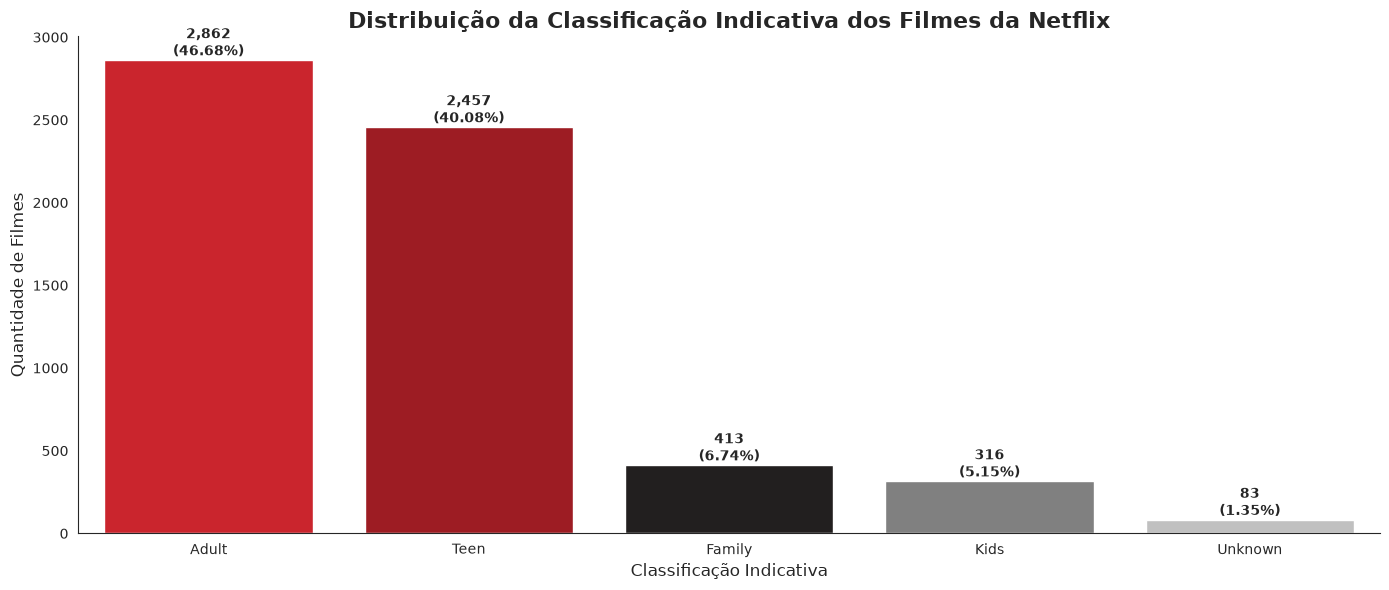

In [199]:
plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=movies_rating,
    x='rating_group',
    y='count',
    palette=['#E50914', '#B20710', '#221F1F', '#808080', '#C0C0C0']
)

for bar, prop in zip(ax.patches, movies_rating['proportion']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}\n({prop:.2f}%)",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

ax.set_title(
    'Distribuição da Classificação Indicativa dos Filmes da Netflix',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('Classificação Indicativa', fontsize=12)
ax.set_ylabel('Quantidade de Filmes', fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Distribuição da Duração dos Filmes em Minutos

In [200]:
netflix_movies['duration'].describe()

count    6131.000000
mean       99.564998
std        28.289504
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration, dtype: float64

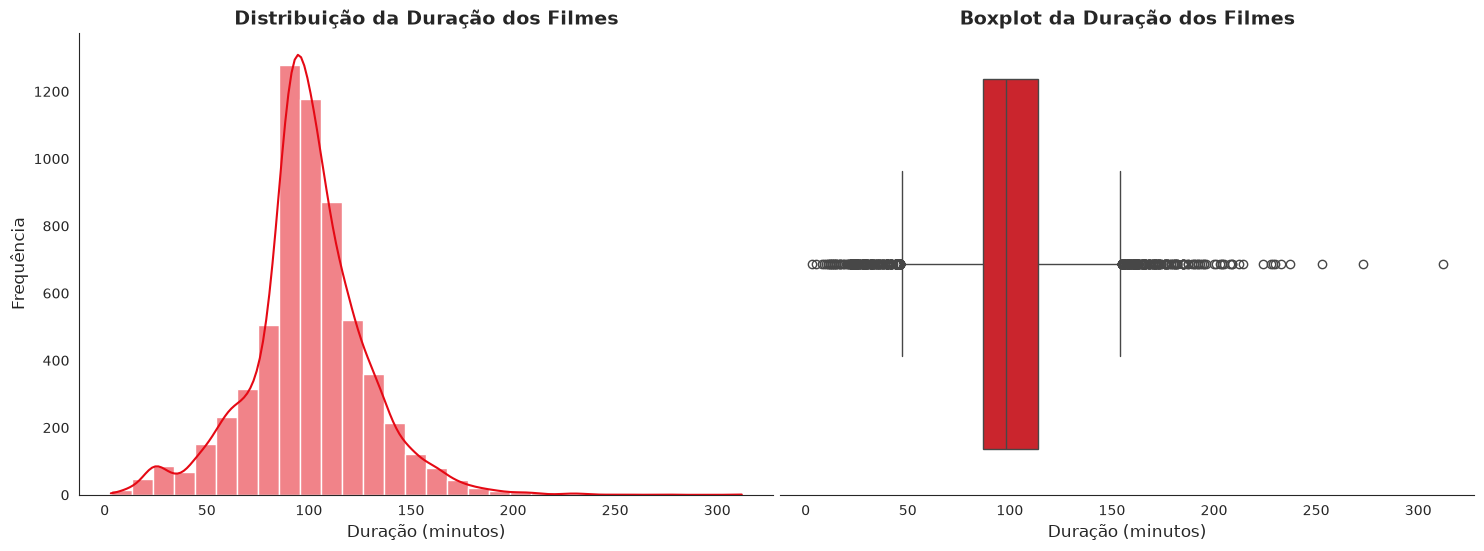

In [201]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tirando o quadriculado
sns.set_style("white")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Histograma
sns.histplot(netflix_movies['duration'], bins=30, kde=True, color='#E50914', ax=axes[0])
axes[0].set_title('Distribuição da Duração dos Filmes', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Duração (minutos)', fontsize=12)
axes[0].set_ylabel('Frequência', fontsize=12)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Boxplot
sns.boxplot(x=netflix_movies['duration'], color='#E50914', ax=axes[1])
axes[1].set_title('Boxplot da Duração dos Filmes', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Duração (minutos)', fontsize=12)
axes[1].spines['top'].set_visible(False)
axes[1].spines['left'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Espaçamento entre os gráficos
plt.subplots_adjust(wspace=0.01)

plt.show()


### Quantidades de Produções de Filmes por Duração (curta, média ou longa)

In [202]:
'''
- Short Film: até 40 min
- Medium-length Film: 41 a 70 min
- Feature Film: acima de 70 min
'''

movies_duration = netflix_movies['duration_category'].value_counts().reset_index()
movies_duration['proportion'] = (movies_duration['count'] / netflix_movies['duration_category'].count() * 100).round(2)
movies_duration

,duration_category,count,proportion
0,Feature Film,5378,87.72
1,Medium-length Film,570,9.30
2,Short Film,183,2.98


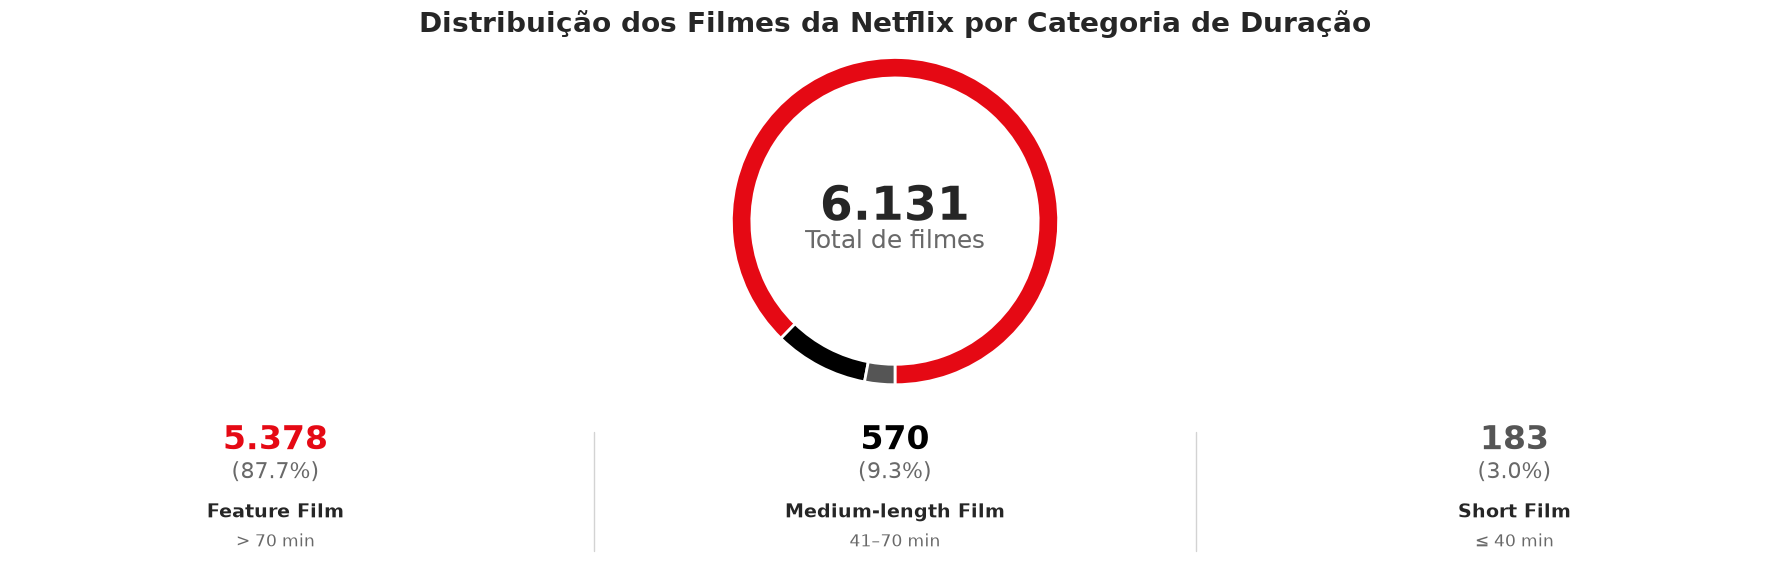

In [203]:
# Dados
labels = ['Feature Film', 'Medium-length Film', 'Short Film']
subtitles = ['> 70 min', '41–70 min', '≤ 40 min']
sizes = movies_duration['count']
colors = ['#E50914', '#000000', '#555555']

# Figura (2/3 gráfico e 1/3 legendas)
fig = plt.figure(figsize=(18, 6))
gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[2, 1])

ax_donut = fig.add_subplot(gs[0])
ax_legend = fig.add_subplot(gs[1])

# Gráfico de rosca
wedges, _ = ax_donut.pie(
    sizes,
    startangle=270,
    colors=colors,
    radius=1.2,
    wedgeprops={'width': 0.15, 'edgecolor': 'white', 'linewidth': 2}
)

total = sizes.sum()

# Texto central
ax_donut.text(0, 0.10, f'{total:,}'.replace(',', '.'), ha='center', va='center', fontsize=34, fontweight='bold')
ax_donut.text(0, -0.15, 'Total de filmes', ha='center', va='center', fontsize=18, color='dimgray')

ax_donut.set_aspect('equal')
ax_donut.axis('off')

# Legendas
ax_legend.axis('off')
x_positions = [0.15, 0.50, 0.85]

for x, label, subtitle, value, color in zip(x_positions, labels, subtitles, sizes, colors):
    pct = value / total * 100

    ax_legend.text(x, 0.75, f'{value:,}'.replace(',', '.'), transform=ax_legend.transAxes, ha='center', fontsize=24, fontweight='bold', color=color)
    ax_legend.text(x, 0.58, f'({pct:.1f}%)', transform=ax_legend.transAxes, ha='center', fontsize=16, color='dimgray')
    ax_legend.text(x, 0.35, label, transform=ax_legend.transAxes, ha='center', fontsize=14, fontweight='bold')
    ax_legend.text(x, 0.18, subtitle, transform=ax_legend.transAxes, ha='center', fontsize=12, color='dimgray')

# Linhas divisórias
for x in [0.33, 0.67]:
    ax_legend.plot([x, x], [0.15, 0.85], transform=ax_legend.transAxes, color='lightgray', linewidth=1)

# Título
fig.suptitle('Distribuição dos Filmes da Netflix por Categoria de Duração', fontsize=20, fontweight='bold', y=0.97)

plt.tight_layout()
plt.show()

### Ano da Adição do Filme ao Catálogo da Netflix

In [204]:
year_added_movie = netflix_movies['year_added'].value_counts().reset_index().sort_values(by='year_added')
year_added_movie

,year_added,count
12,2008,1
11,2009,2
13,2010,1
8,2011,13
10,2012,3
9,2013,6
7,2014,19
6,2015,56
5,2016,253
4,2017,839


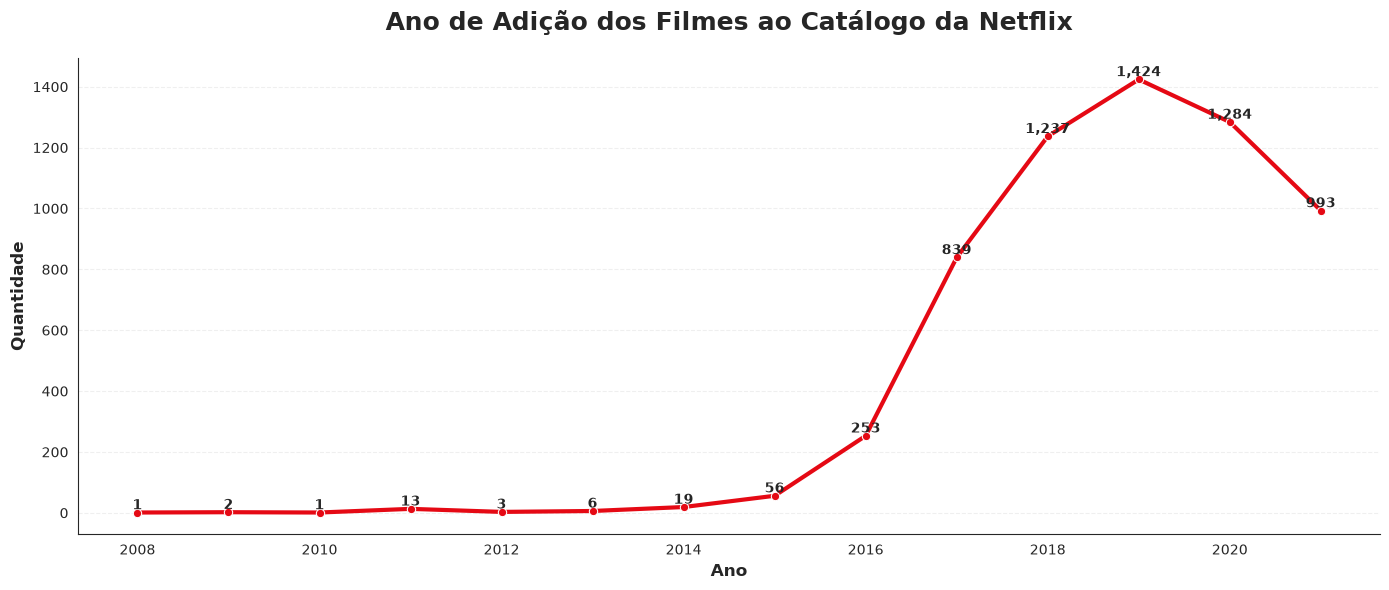

In [205]:
plt.figure(figsize=(14, 6))

ax = sns.lineplot(
    data=year_added_movie,
    x='year_added',
    y='count',
    marker='o',
    linewidth=3,
    color='#E50914'
)

# Adiciona os valores em cada ponto
for x, y in zip(year_added_movie['year_added'], year_added_movie['count']):
    ax.text(
        x, y,
        f'{y:,}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Remove linhas de cima e direita
sns.despine(top=True, right=True)

# Títulos e rótulos
plt.title(
    'Ano de Adição dos Filmes ao Catálogo da Netflix',
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.xlabel('Ano', fontsize=12, fontweight='bold')
plt.ylabel('Quantidade', fontsize=12, fontweight='bold')

# Grade discreta
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [211]:
week_added_movie = (
    netflix_movies
    .assign(
        week_added=pd.to_datetime(netflix_movies['date_added']).dt.to_period('W').dt.start_time
    )
    .groupby('week_added')
    .size()
    .reset_index(name='count')
    .sort_values('week_added')
)

week_added_movie.head()

,week_added,count
0,2007-12-31,1
1,2009-05-04,1
2,2009-11-16,1
3,2010-11-01,1
4,2011-05-16,1


In [ ]:
fig = px.line(
    week_added_movie,
    x='week_added',
    y='count',
    title='Número de títulos adicionados à Netflix por semana'
)

fig.update_traces(
    line=dict(color='#E50914', width=3)
)

fig.update_layout(
    xaxis_title='Semana de adição',
    yaxis_title='Quantidade de títulos',
    template='plotly_white',
    hovermode='x unified'
)

fig.show()

### Distribuição dos Filmes do Catálogo da Netflix pela Década de Lançamento

In [207]:
release_decade_movie = netflix_movies['release_decade'].value_counts().reset_index().sort_values(by='release_decade')
release_decade_movie

,release_decade,count
7,1940,13
8,1950,11
6,1960,23
5,1970,66
4,1980,122
3,1990,241
2,2000,677
0,2010,4184
1,2020,794


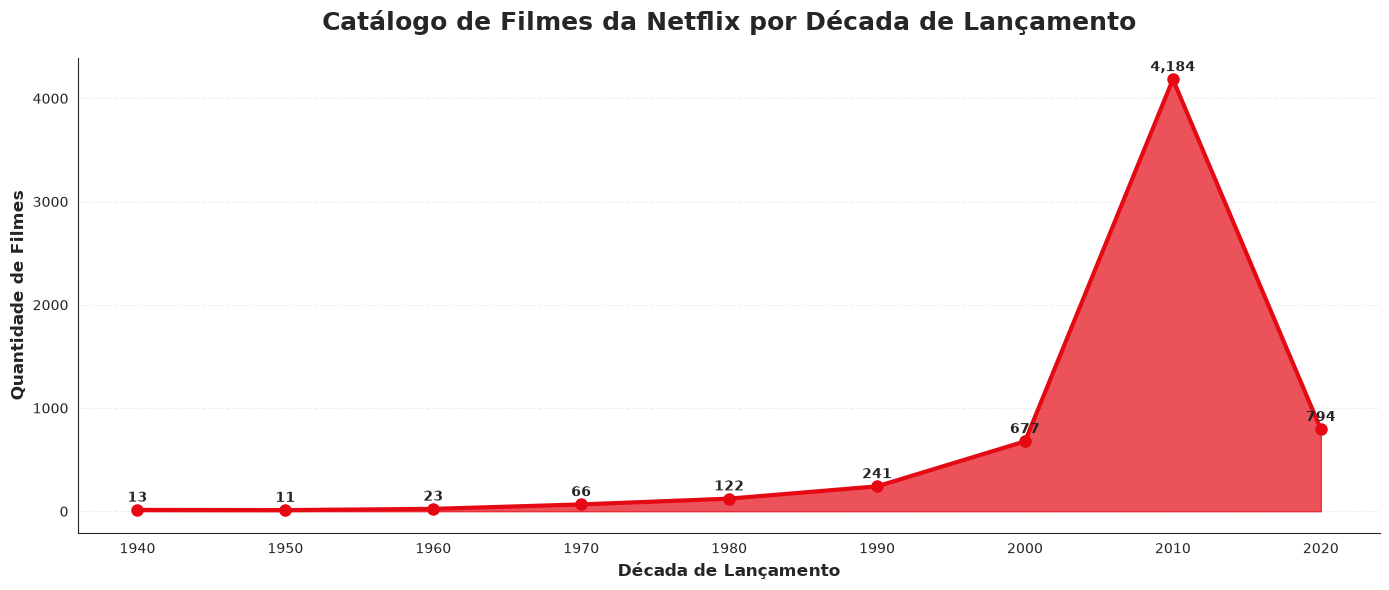

In [208]:
plt.figure(figsize=(14, 6))

plt.fill_between(
    release_decade_movie['release_decade'],
    release_decade_movie['count'],
    color='#E50914',
    alpha=0.7
)

plt.plot(
    release_decade_movie['release_decade'],
    release_decade_movie['count'],
    color='#E50914',
    linewidth=3,
    marker='o',
    markersize=8
)

for _, row in release_decade_movie.iterrows():
    plt.text(
        row['release_decade'],
        row['count'] + 80,
        f"{row['count']:,}",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    'Catálogo de Filmes da Netflix por Década de Lançamento',
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.xlabel('Década de Lançamento', fontsize=12, fontweight='bold')
plt.ylabel('Quantidade de Filmes', fontsize=12, fontweight='bold')

plt.xticks(release_decade_movie['release_decade'])

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [77]:
delay_added_movie = netflix_movies['delay_added'].value_counts().reset_index().sort_values(by='delay_added')
delay_added_movie.head(10)

,delay_added,count
0,0,1864
1,1,1178
2,2,491
3,3,347
4,4,273
5,5,191
6,6,181
8,7,139
7,8,147
9,9,128


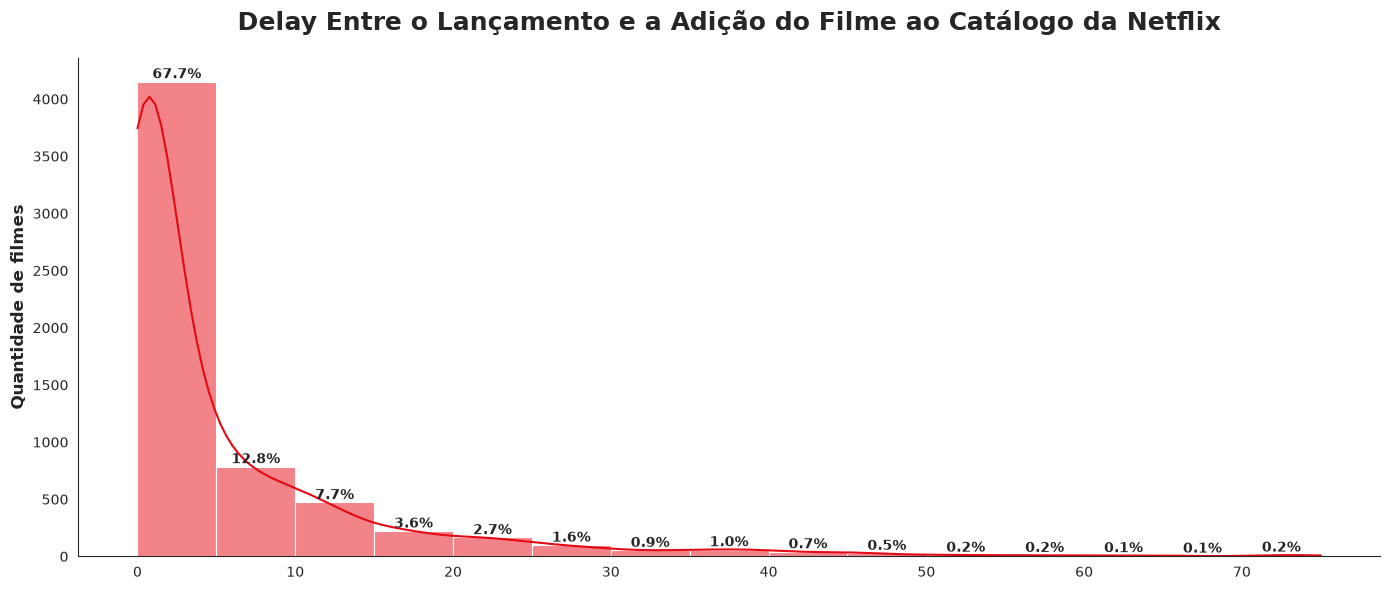

In [85]:
plt.figure(figsize=(14, 6))

ax = sns.histplot(
    data=netflix_movies,
    x='delay_added',
    bins=15,
    color='#E50914',
    edgecolor='white',
    linewidth=0.8,
    kde=True,
    stat='count'
)

# Adiciona a porcentagem acima de cada barra
total = len(netflix_movies)
for patch in ax.patches:
    height = patch.get_height()
    if height > 0:
        percentage = height / total * 100
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            height,
            f'{percentage:.1f}%',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

plt.title('Delay Entre o Lançamento e a Adição do Filme ao Catálogo da Netflix', 
    fontsize=18, fontweight='bold',pad=20)

plt.xlabel('',
    fontsize=12,fontweight='bold')

plt.ylabel('Quantidade de filmes',
    fontsize=12,fontweight='bold')

sns.despine(top=True,right=True)
plt.tight_layout()
plt.show()

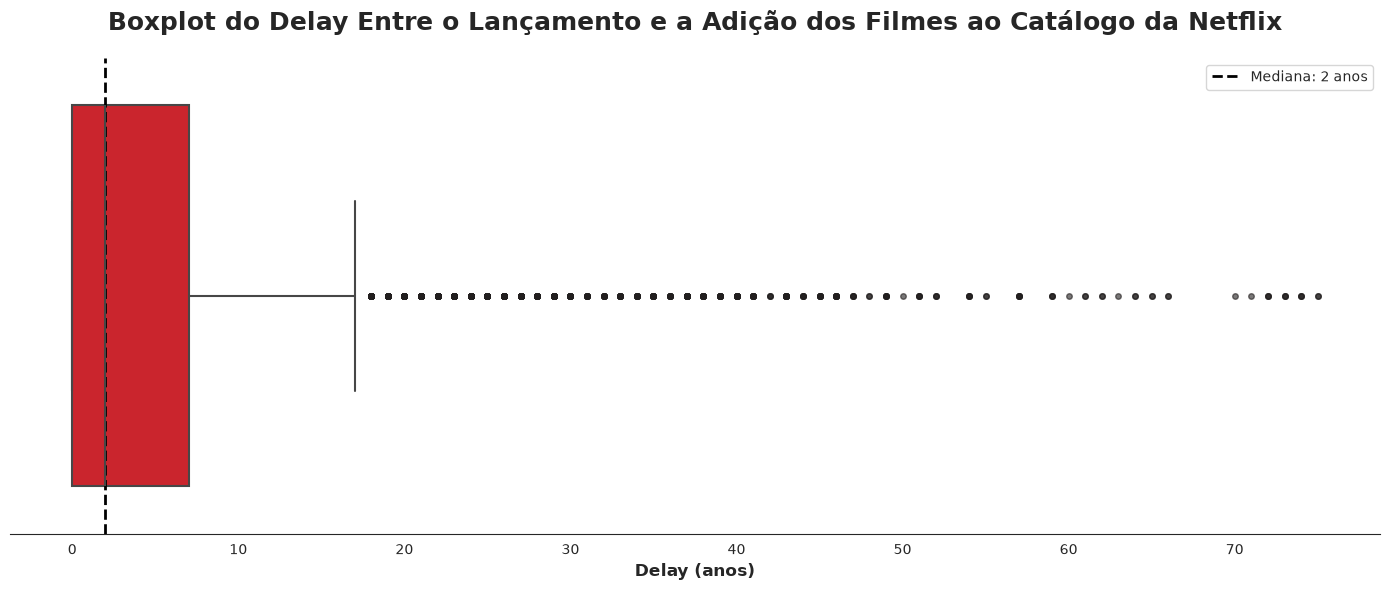

In [179]:
plt.figure(figsize=(14, 6))
ax = sns.boxplot(
    data=netflix_movies,
    x='delay_added',
    color='#E50914',
    linewidth=1.5,
    flierprops={
        'marker': 'o',
        'markerfacecolor': '#221F1F',
        'markeredgecolor': '#221F1F',
        'markersize': 4,
        'alpha': 0.6
    }
)

# Mediana
median = netflix_movies['delay_added'].median()

plt.axvline(
    median,
    color='black',
    linestyle='--',
    linewidth=2,
    label=f'Mediana: {median:.0f} anos'
)

plt.title(
    'Boxplot do Delay Entre o Lançamento e a Adição dos Filmes ao Catálogo da Netflix',
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.xlabel(
    'Delay (anos)',
    fontsize=12,
    fontweight='bold'
)

sns.despine(top=True, right=True, left=True)

plt.legend()
plt.tight_layout()
plt.show()

## Programas de Televisão

### Quantidades de Produções de Programas de Televisão por País

In [108]:
tv_country = netflix_tv['main_country'].value_counts().reset_index()
tv_country['proportion'] = (tv_country['count'] / netflix_type['count'].sum() * 100).round(2)
tv_country.head(20)

,main_country,count,proportion
0,United States,847,9.62
1,Unknown,391,4.44
2,United Kingdom,246,2.79
3,Japan,174,1.98
4,South Korea,165,1.87
5,Canada,84,0.95
6,India,81,0.92
7,Taiwan,70,0.79
8,France,64,0.73
9,Australia,56,0.64


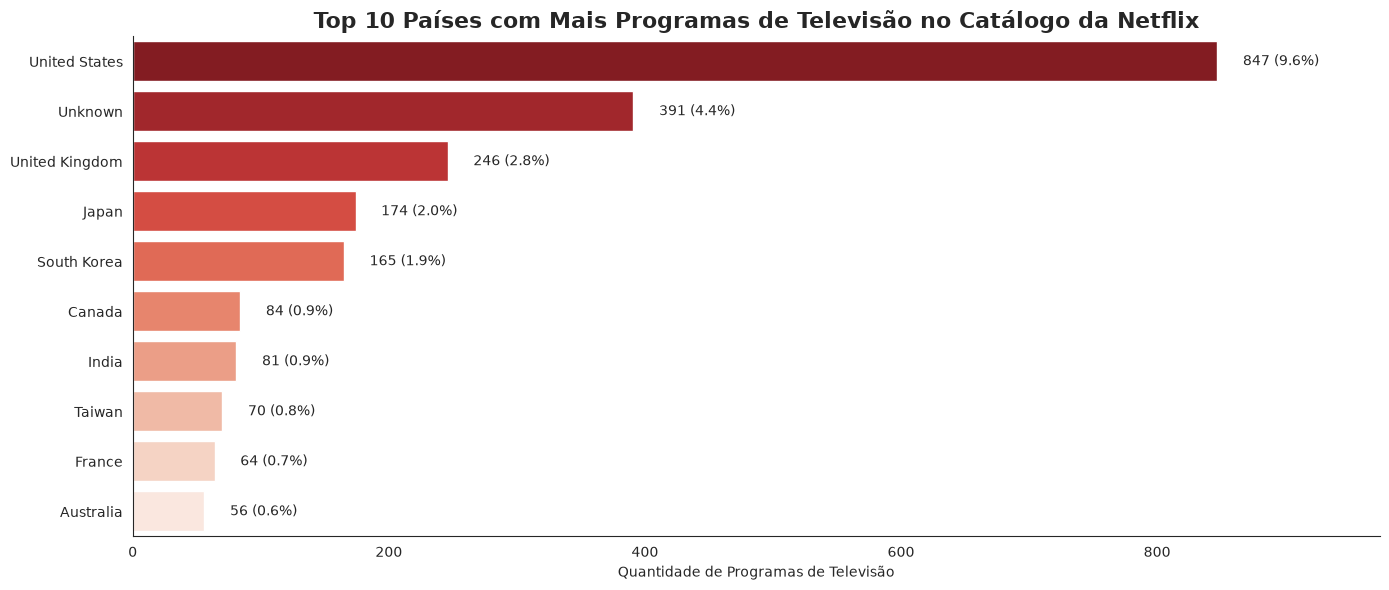

In [109]:
plt.figure(figsize=(14, 6))

top10 = tv_country.head(10)

ax = sns.barplot(data=top10, x='count', y='main_country', palette='Reds_r')

for i, (_, row) in enumerate(top10.iterrows()):
    ax.text(
        row['count'] + 20,
        i,
        f"{row['count']} ({row['proportion']:.1f}%)",
        va='center',
        fontsize=10
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title('Top 10 Países com Mais Programas de Televisão no Catálogo da Netflix', fontsize=16, fontweight='bold')
plt.xlabel('Quantidade de Programas de Televisão')
plt.ylabel('')
plt.xlim(0, top10['count'].max() * 1.15)
plt.tight_layout()
plt.show()

### Quantidades de Produções de Programas de Televisão por Continente

In [110]:
tv_continent = netflix_tv['continent'].value_counts().reset_index()
tv_continent['proportion'] = (tv_continent['count'] / netflix_type['count'].sum() * 100).round(2)
tv_continent

,continent,count,proportion
0,North America,979,11.12
1,Asia,617,7.01
2,Europe,520,5.90
3,Unknown,392,4.45
4,South America,78,0.89
5,Oceania,58,0.66
6,Africa,31,0.35
7,Central America,1,0.01


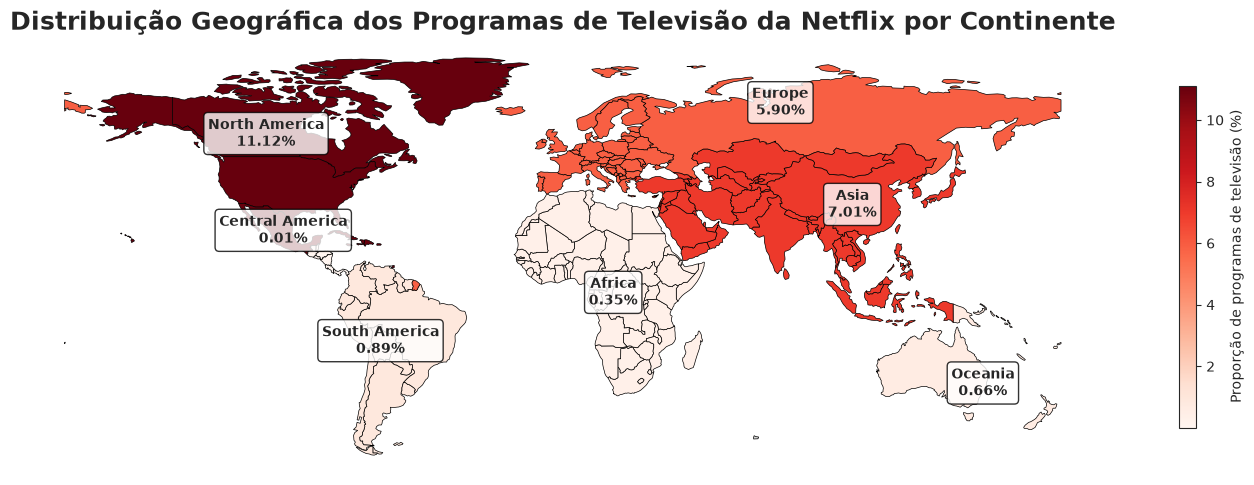

In [112]:
# Carregar mapa-múndi (compatível com GeoPandas >= 1.0)
world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")

# Ajustar continentes
world['continent'] = world['CONTINENT']

# Separar América Central da América do Norte
central_america = ['Belize', 'Costa Rica', 'El Salvador', 'Guatemala',
                   'Honduras', 'Nicaragua', 'Panama']
world.loc[world['ADMIN'].isin(central_america), 'continent'] = 'Central America'

# Remover Antártida
world = world[world['continent'] != 'Antarctica']

# Juntar os dados ao mapa
world = world.merge(
    tv_continent[['continent', 'proportion']],
    on='continent',
    how='left'
)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

world.plot(
    column='proportion',
    cmap='Reds',
    linewidth=0.5,
    edgecolor='black',
    legend=True,
    legend_kwds={
        'label': 'Proporção de programas de televisão (%)',
        'shrink': 0.6
    },
    missing_kwds={
        'color': 'lightgrey',
        'label': 'Sem dados'
    },
    ax=ax
)

# Rótulos dos continentes
continents = world.dissolve(by='continent')

for continent, row in continents.iterrows():

    if continent == 'Unknown':
        continue

    centroid = row.geometry.centroid

    prop = tv_continent.loc[
        tv_continent['continent'] == continent,
        'proportion'
    ]

    if len(prop) > 0:

        x, y = centroid.x, centroid.y

        # Ajustes manuais para melhor posicionamento
        if continent == 'North America':
            x -= 15
        elif continent == 'South America':
            x -= 5
        elif continent == 'Europe':
            y += 8
        elif continent == 'Asia':
            x += 20
        elif continent == 'Africa':
            y -= 5
        elif continent == 'Oceania':
            x += 15
            y -= 5
        elif continent == 'Central America':
            x -= 15
            y += 10

        ax.text(
            x,
            y,
            f'{continent}\n{prop.values[0]:.2f}%',
            ha='center',
            va='center',
            fontsize=10,
            fontweight='bold',
            bbox=dict(
                facecolor='white',
                edgecolor='black',
                alpha=0.8,
                boxstyle='round,pad=0.3'
            )
        )

ax.set_title(
    'Distribuição Geográfica dos Programas de Televisão da Netflix por Continente',
    fontsize=18,
    fontweight='bold'
)

ax.axis('off')

plt.tight_layout()
plt.show()

### Quantidades de Programas de Televisão por Idioma Principal

In [118]:
tv_language = netflix_tv['language'].value_counts().reset_index()
tv_language['proportion'] = (tv_language['count'] / netflix_type['count'].sum() * 100).round(2)
tv_language.head(10)

,language,count,proportion
0,English,1274,14.47
1,Unknown,392,4.45
2,Japanese,174,1.98
3,Korean,165,1.87
4,Spanish,151,1.71
5,Mandarin,111,1.26
6,Hindi,81,0.92
7,French,76,0.86
8,Turkish,30,0.34
9,Arabic,29,0.33


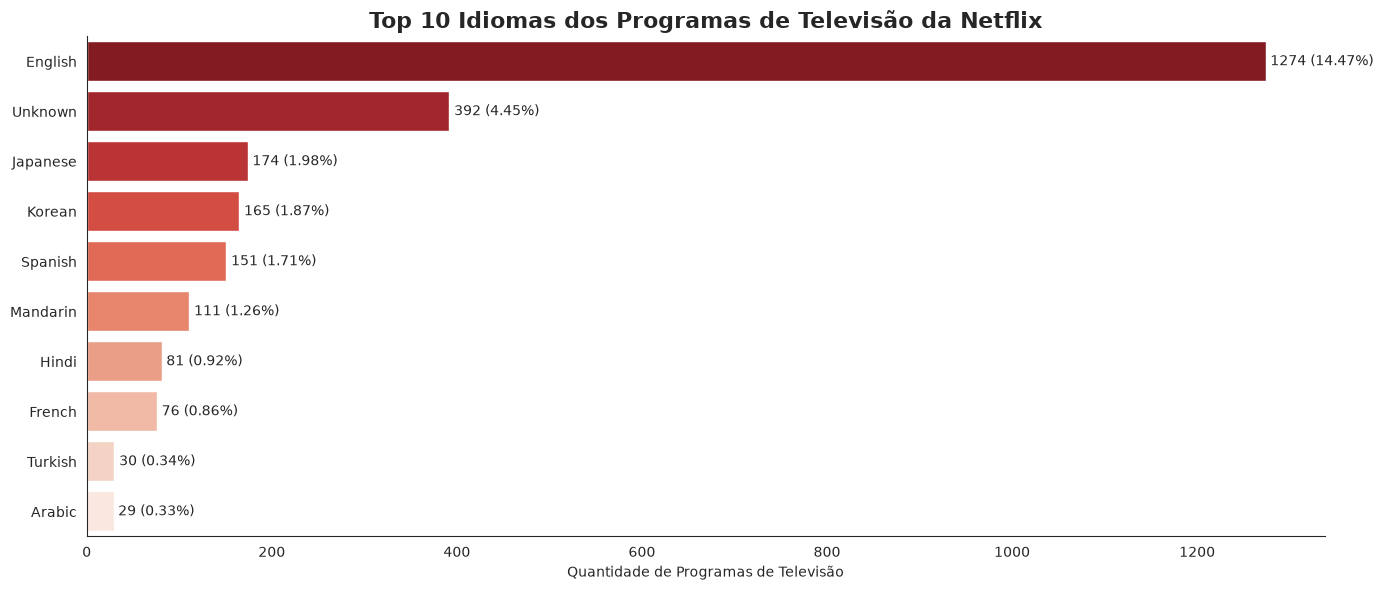

In [120]:
plt.figure(figsize=(14, 6))

top10 = tv_language.head(10)

ax = sns.barplot(
    data=top10,
    x='count',
    y='language',
    palette='Reds_r'
)

for i, (_, row) in enumerate(top10.iterrows()):
    ax.text(
        row['count'] + 5,
        i,
        f"{row['count']} ({row['proportion']:.2f}%)",
        va='center',
        fontsize=10
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title(
    'Top 10 Idiomas dos Programas de Televisão da Netflix',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Quantidade de Programas de Televisão')
plt.ylabel('')

plt.tight_layout()
plt.show()

### Quantidades de Programas de Televisão por Gênero Principal

In [ ]:
tv_genre = netflix_tv['genre'].value_counts().reset_index()
tv_genre['proportion'] = (tv_genre['count'] / netflix_type['count'].sum() * 100).round(2)
tv_genre.head(10)

,genre,count,proportion
0,International,774,8.79
1,Crime,399,4.53
2,Family,388,4.41
3,TV Shows,275,3.12
4,Documentary,221,2.51
5,Anime,176,2.00
6,Comedy,154,1.75
7,Reality,120,1.36
8,Drama,67,0.76
9,Action & Adventure,40,0.45


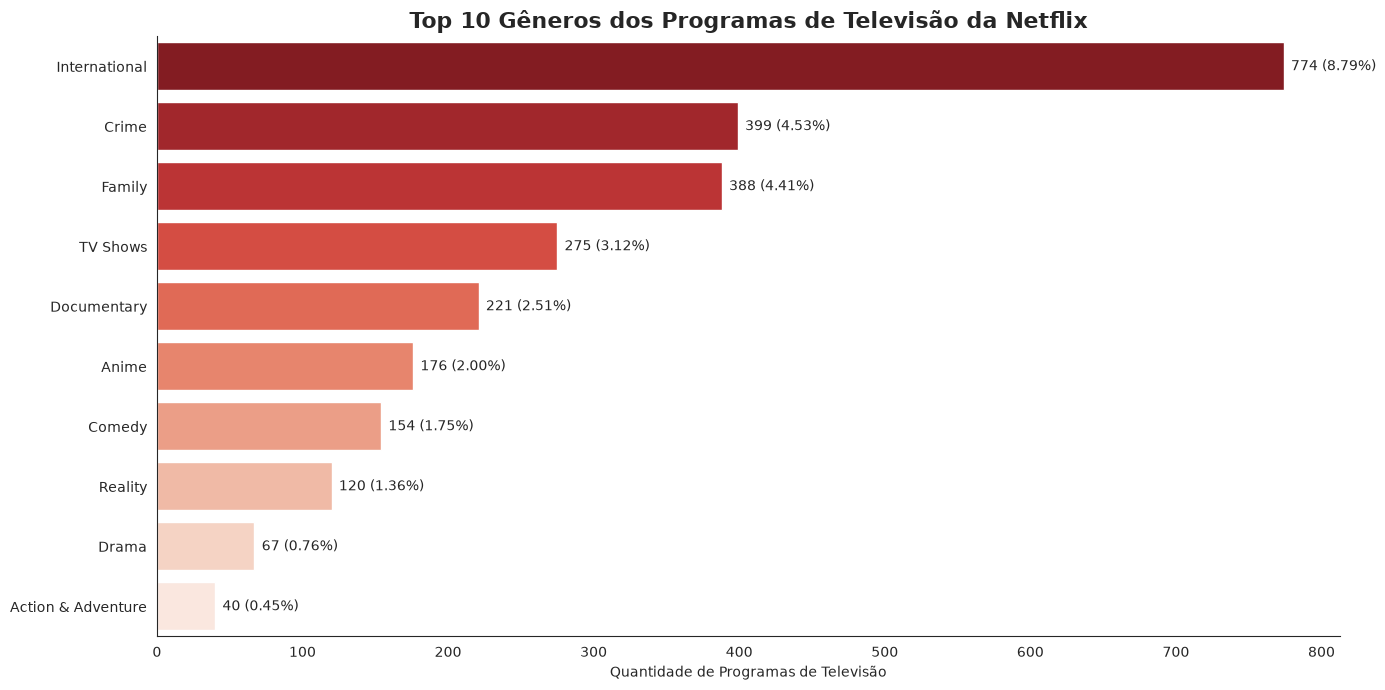

In [122]:
plt.figure(figsize=(14, 7))

top10 = tv_genre.head(10)

ax = sns.barplot(
    data=top10,
    x='count',
    y='genre',
    palette='Reds_r'
)

for i, (_, row) in enumerate(top10.iterrows()):
    ax.text(
        row['count'] + 5,
        i,
        f"{row['count']} ({row['proportion']:.2f}%)",
        va='center',
        fontsize=10
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title(
    'Top 10 Gêneros dos Programas de Televisão da Netflix',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Quantidade de Programas de Televisão')
plt.ylabel('')

plt.tight_layout()
plt.show()

### Quantidades de Programas de Televisão por Classificação Indicativa

In [123]:
tv_rating = netflix_tv['rating_group'].value_counts().reset_index()
tv_rating['proportion'] = (tv_rating['count'] / netflix_type['count'].sum() * 100).round(2)
tv_rating

,rating_group,count,proportion
0,Adult,1147,13.02
1,Teen,1056,11.99
2,Kids,372,4.22
3,Family,94,1.07
4,Unknown,7,0.08


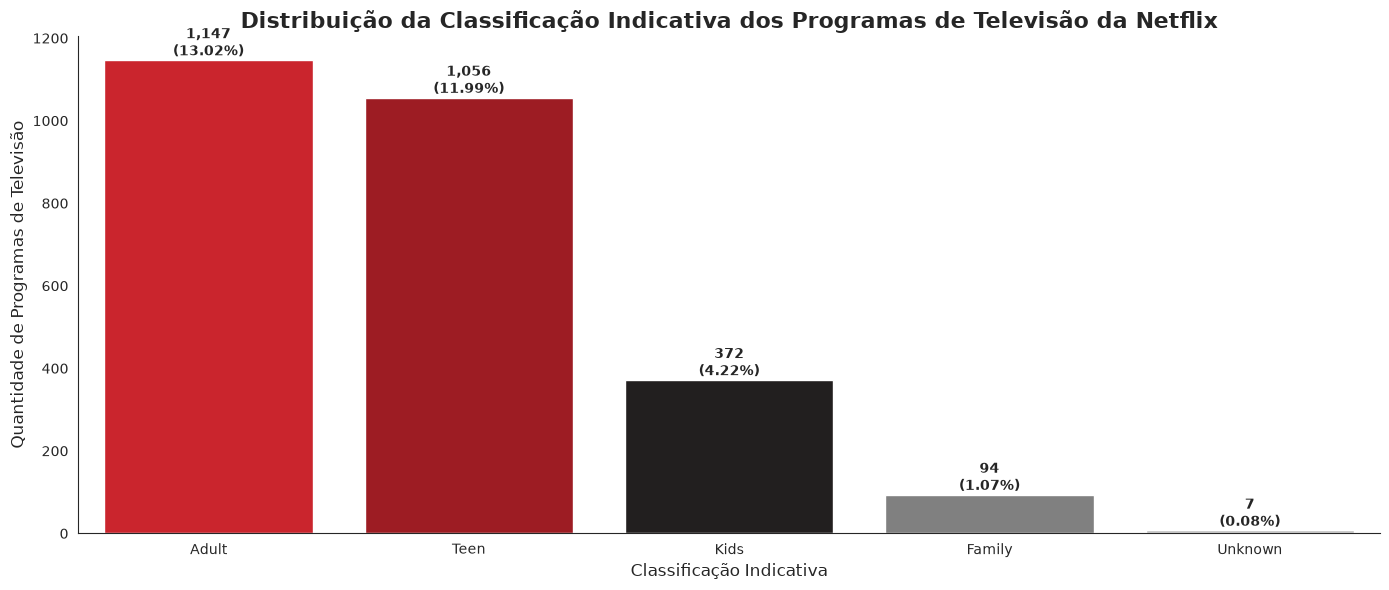

In [125]:
plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=tv_rating,
    x='rating_group',
    y='count',
    palette=['#E50914', '#B20710', '#221F1F', '#808080', '#C0C0C0']
)

for bar, prop in zip(ax.patches, tv_rating['proportion']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}\n({prop:.2f}%)",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

ax.set_title(
    'Distribuição da Classificação Indicativa dos Programas de Televisão da Netflix',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('Classificação Indicativa', fontsize=12)
ax.set_ylabel('Quantidade de Programas de Televisão', fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Quantidade de Programas de Televisão por Década de Lançamento

In [126]:
netflix_tv['release_decade'] = (
    netflix_tv['release_year'] // 10
) * 10

tv_decade = (
    netflix_tv['release_decade']
    .value_counts()
    .sort_index()
    .reset_index()
)

tv_decade.columns = ['decade', 'count']

tv_decade['proportion'] = (
    tv_decade['count']
    / tv_decade['count'].sum()
    * 100
).round(2)

tv_decade

,decade,count,proportion
0,1920,1,0.04
1,1940,2,0.07
2,1960,2,0.07
3,1970,4,0.15
4,1980,7,0.26
5,1990,33,1.23
6,2000,133,4.97
7,2010,1743,65.13
8,2020,751,28.06


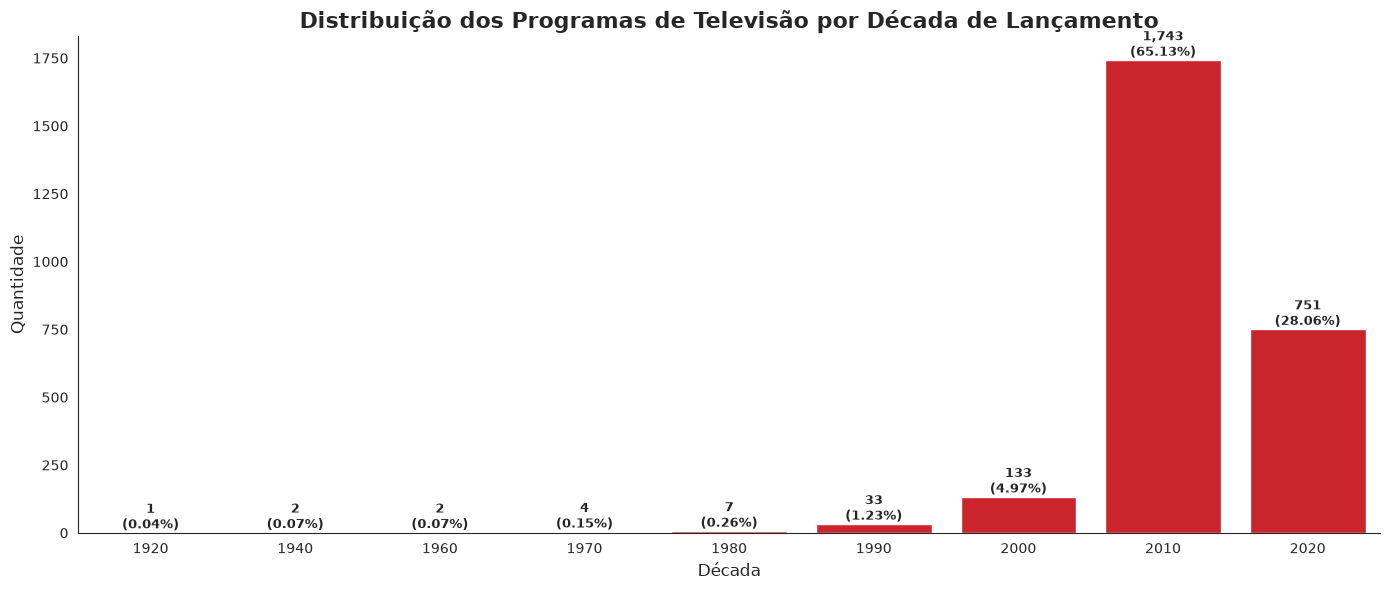

In [130]:
plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=tv_decade,
    x='decade',
    y='count',
    color='#E50914'
)

for bar, prop in zip(ax.patches, tv_decade['proportion']):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}\n({prop:.2f}%)",
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

ax.set_title(
    'Distribuição dos Programas de Televisão por Década de Lançamento',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('Década', fontsize=12)
ax.set_ylabel('Quantidade', fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Quantidade de Programas de Televisão Adicionados ao Catálogo por Ano

In [133]:
netflix_tv['date_added'] = pd.to_datetime(
    netflix_tv['date_added'],
    errors='coerce'
)
tv_added_year = (
    netflix_tv['date_added']
    .dt.year
    .value_counts()
    .sort_index()
    .rename_axis('year_added')
    .reset_index(name='count')
)

tv_added_year

,year_added,count
0,2008,1
1,2013,7
2,2014,7
3,2015,29
4,2016,178
5,2017,349
6,2018,412
7,2019,592
8,2020,596
9,2021,505


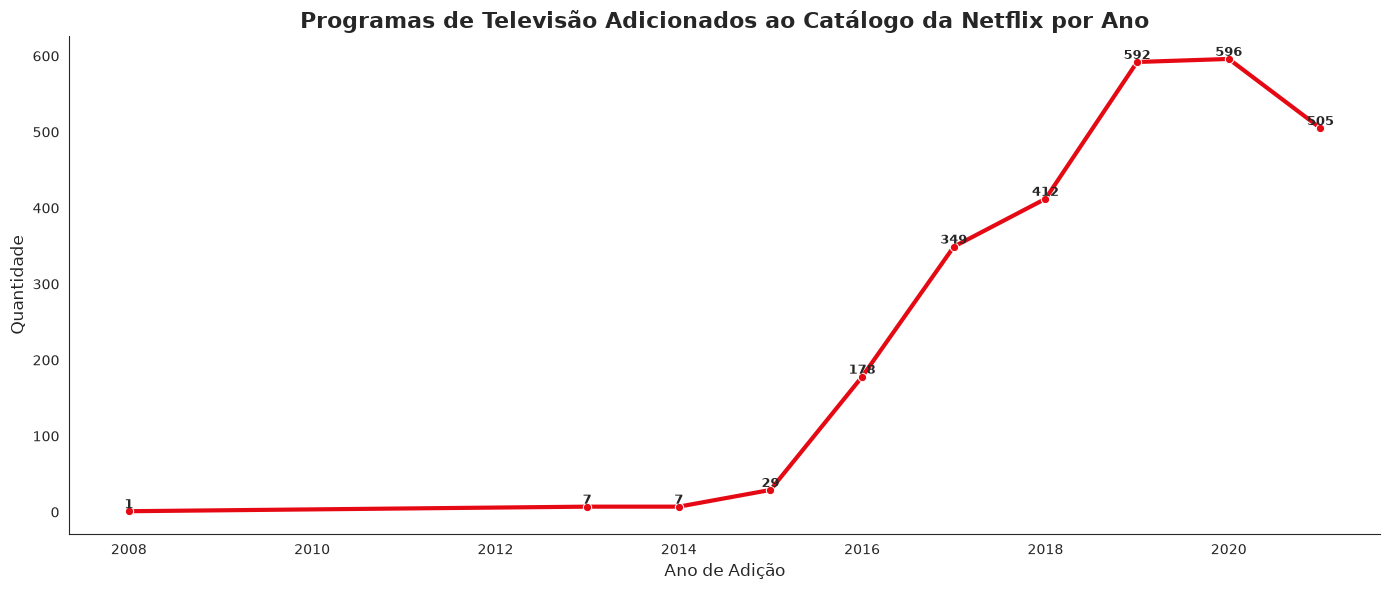

In [134]:
plt.figure(figsize=(14, 6))

ax = sns.lineplot(
    data=tv_added_year,
    x='year_added',
    y='count',
    marker='o',
    color='#E50914',
    linewidth=3
)

for _, row in tv_added_year.iterrows():

    ax.text(
        row['year_added'],
        row['count'],
        f"{int(row['count'])}",
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

ax.set_title(
    'Programas de Televisão Adicionados ao Catálogo da Netflix por Ano',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('Ano de Adição', fontsize=12)
ax.set_ylabel('Quantidade', fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Quantidade de Programas de Televisão por Número de Temporadas

In [143]:
tv_seasons = (
    netflix_tv['duration']
    .value_counts()
    .rename_axis('season_number')
    .reset_index(name='count')
)

tv_seasons = (
    tv_seasons
    .sort_values('season_number')
    .reset_index(drop=True)
)

tv_seasons['proportion'] = (
    tv_seasons['count']
    / tv_seasons['count'].sum()
    * 100
).round(2)

tv_seasons.head()

,season_number,count,proportion
0,1,1793,67.00
1,2,425,15.88
2,3,199,7.44
3,4,95,3.55
4,5,65,2.43


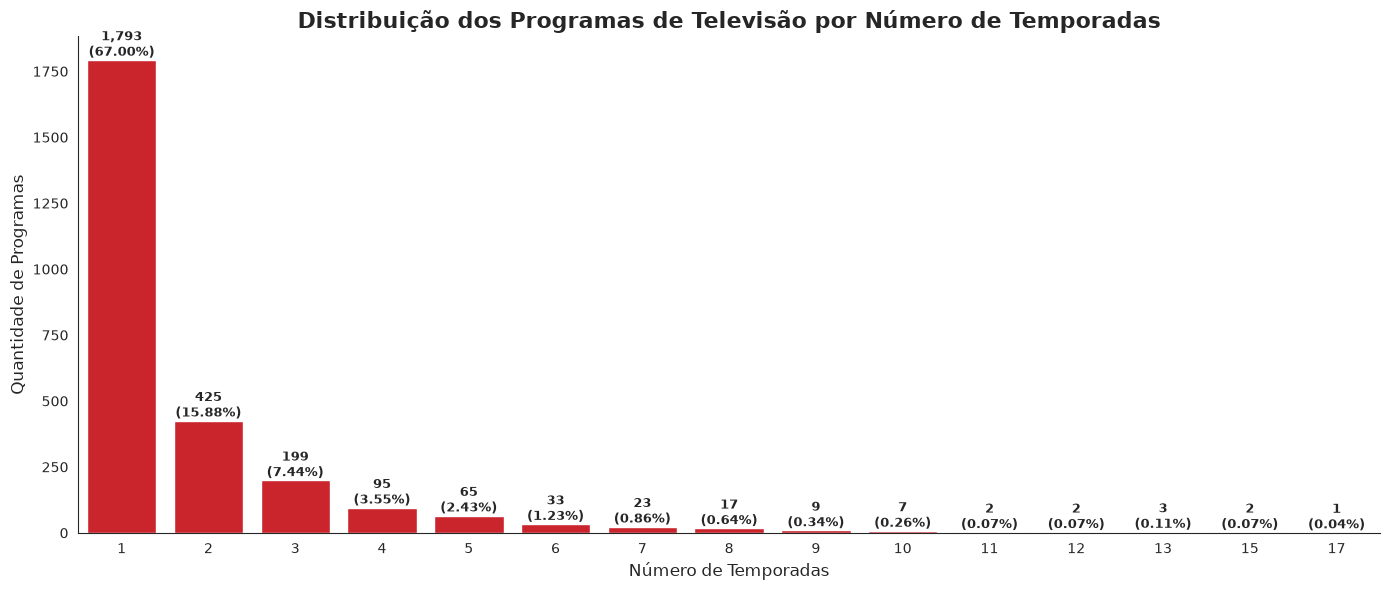

In [ ]:
plt.figure(figsize=(14, 6))

ax = sns.barplot(data=tv_seasons,
    x='season_number',
    y='count',
    color='#E50914'
)

for bar, prop in zip(ax.patches, tv_seasons['proportion']):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}\n({prop:.2f}%)",
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

ax.set_title('Distribuição dos Programas de Televisão por Número de Temporadas',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('Número de Temporadas', fontsize=12)
ax.set_ylabel('Quantidade de Programas', fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Agrupamento dos Programas de Televisão por Extensão

In [150]:
netflix_tv['season_number'] = netflix_tv['duration']

netflix_tv['season_group'] = np.select(
    [
        netflix_tv['season_number'] == 1,
        netflix_tv['season_number'].between(2, 3),
        netflix_tv['season_number'].between(4, 6),
        netflix_tv['season_number'] >= 7
    ],
    [
        'Minissérie (1 temporada)',
        'Curta (2–3 temporadas)',
        'Média (4–6 temporadas)',
        'Longa (7+ temporadas)'
    ],
    default='Desconhecido'
)

tv_season_group = (
    netflix_tv['season_group']
    .value_counts()
    .rename_axis('season_group')
    .reset_index(name='count')
)

tv_season_group['proportion'] = (
    tv_season_group['count']
    / tv_season_group['count'].sum()
    * 100
).round(2)

tv_season_group

,season_group,count,proportion
0,Minissérie (1 temporada),1793,67.00
1,Curta (2–3 temporadas),624,23.32
2,Média (4–6 temporadas),193,7.21
3,Longa (7+ temporadas),66,2.47


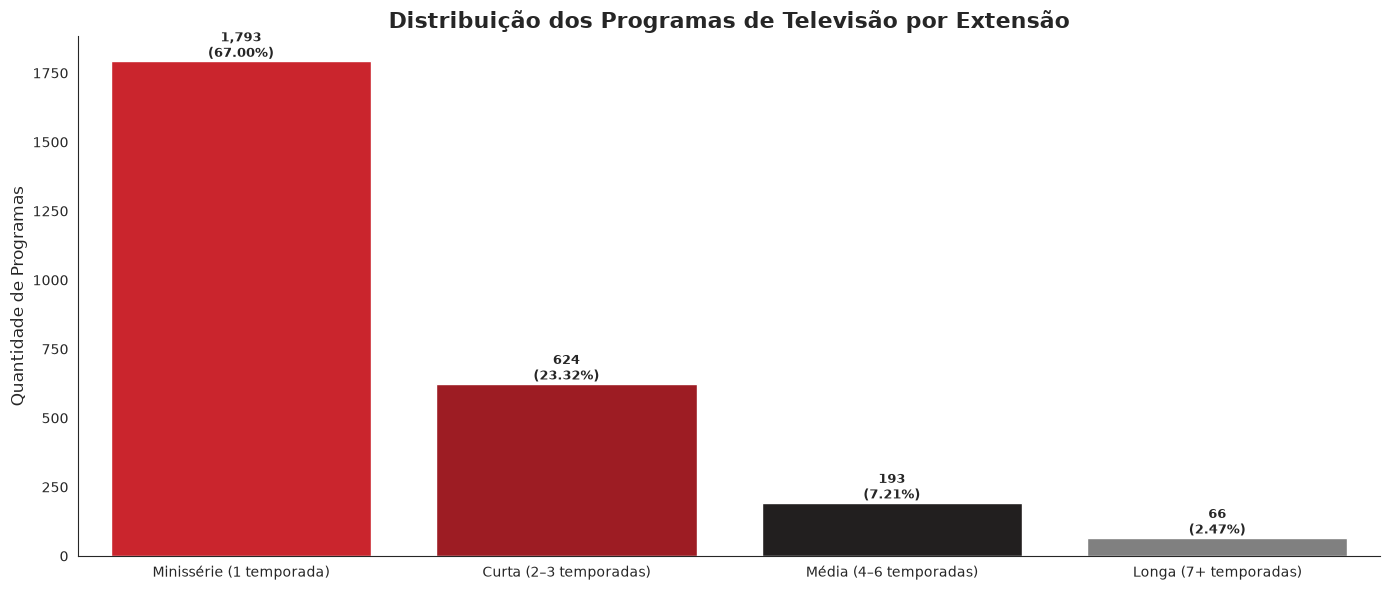

In [153]:
plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=tv_season_group,
    x='season_group',
    y='count',
    palette=['#E50914', '#B20710', '#221F1F', '#808080']
)

for bar, prop in zip(ax.patches, tv_season_group['proportion']):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}\n({prop:.2f}%)",
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

ax.set_title(
    'Distribuição dos Programas de Televisão por Extensão',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('')
ax.set_ylabel('Quantidade de Programas', fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Tempo Entre o Lançamento e a Entrada no Catálogo da Netflix

In [165]:
netflix_tv['date_added'] = pd.to_datetime(
    netflix_tv['date_added'],
    format='%B %d, %Y',
    errors='coerce'
)

netflix_tv['delay'] = (
    netflix_tv['date_added'].dt.year
    - netflix_tv['release_year']
)

tv_delay = netflix_tv['delay'].dropna()

tv_delay.describe()

count    2676.000000
mean        2.303812
std         5.325165
min        -4.000000
25%         0.000000
50%         0.000000
75%         2.000000
max        93.000000
Name: delay, dtype: float64

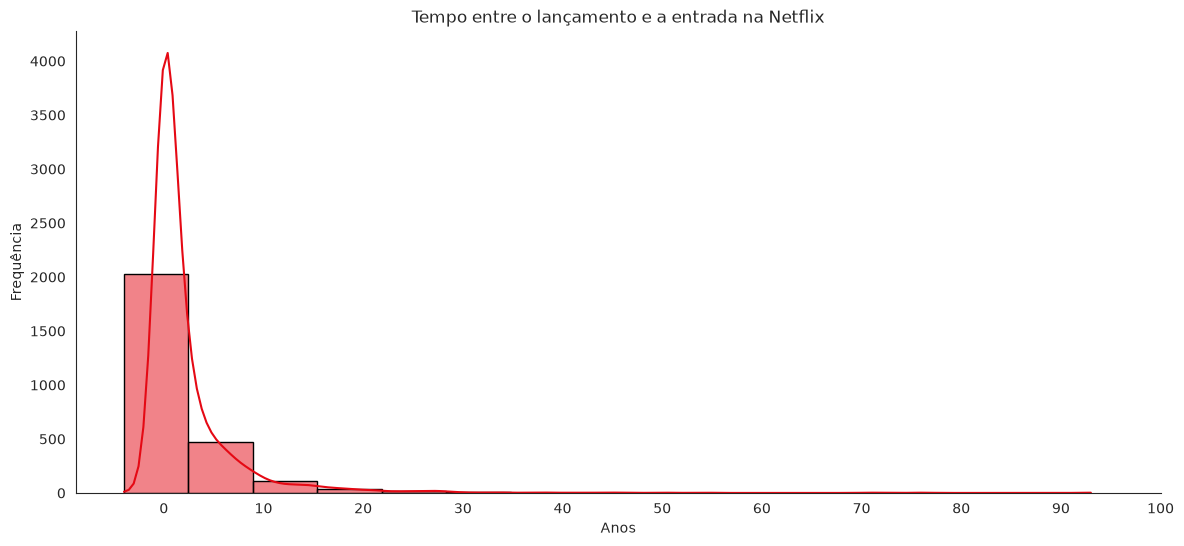

In [ ]:
plt.figure(figsize=(14, 6))

sns.histplot(
    tv_delay,
    bins=15,
    kde=True,
    color='#E50914',
    edgecolor='black'
)

plt.title('Tempo entre o lançamento e a entrada na Netflix')
plt.xlabel('Anos')
plt.ylabel('Frequência')

plt.xticks(range(0, int(tv_delay.max()) + 10, 10))
sns.despine(top=True, right=True)
plt.show()

### Boxplot do Tempo de Entrada no Catálogo

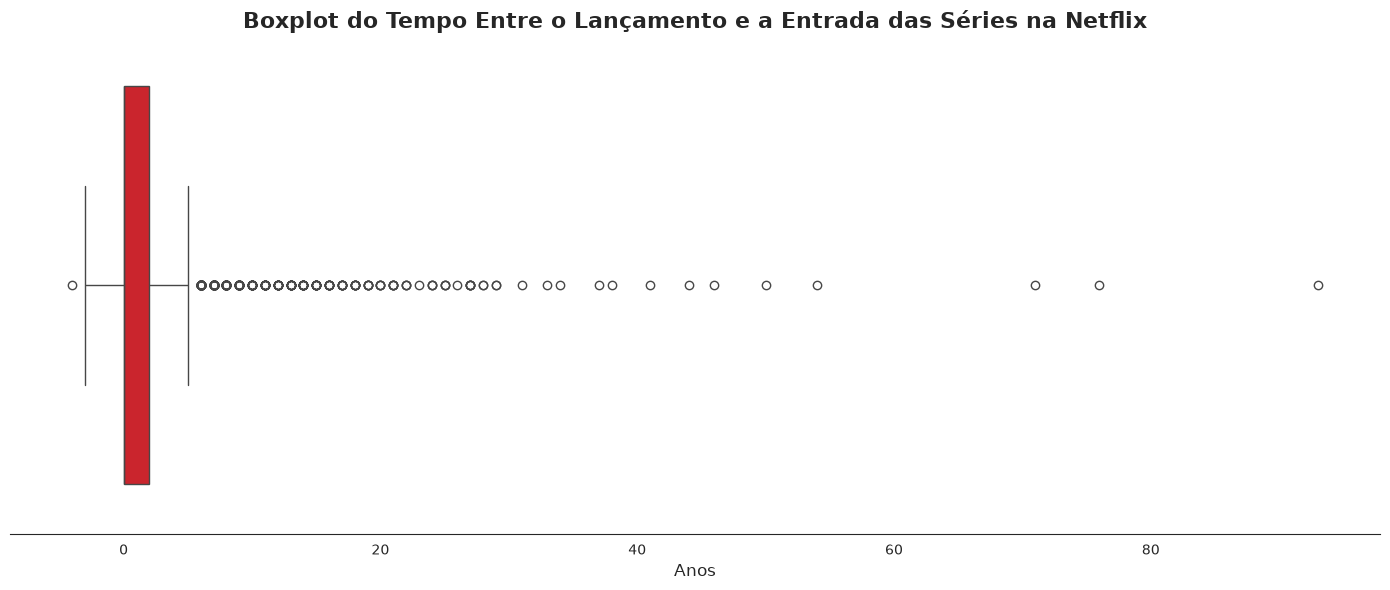

In [174]:
plt.figure(figsize=(14, 6))

ax = sns.boxplot(
    x=tv_delay,
    color='#E50914'
)

ax.set_title(
    'Boxplot do Tempo Entre o Lançamento e a Entrada das Séries na Netflix',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('Anos', fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()